# Batch Preprocessing van Dot-woorden met EdgeConnect

Dit notebook leest alle afbeeldingen uit een input-folder, haalt ze door het getrainde EdgeConnect model, en slaat de gegenereerde beelden op in een output-folder.

In [2]:
import sys
import torch
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as F
import imageio.v2 as imageio_v2
from skimage.color import rgb2gray, gray2rgb
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

# Pad naar de model classes toevoegen
sys.path.insert(0, "/workspace/3a-edgeconnect/src")
from networks import EdgeGenerator

# Definieer de mappen
CKPT_DIR   = Path("/workspace/3a-edgeconnect/checkpoints/text_dots_1")
INPUT_DIR  = Path("/workspace/data/test_input")
OUTPUT_DIR = Path("/workspace/3a-edgeconnect/output/edge_output_1")

# Maak de output map aan als deze nog niet bestaat
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Het model inladen hoeft maar 1 keer voor de hele batch
print("Model laden...")
checkpoint = torch.load(CKPT_DIR / "EdgeModel_gen.pth", map_location="cpu")
model = EdgeGenerator(use_spectral_norm=True)
model.load_state_dict(checkpoint["generator"])
model.eval()
print("Model succesvol geladen!")

Model laden...
Model succesvol geladen!


In [4]:
def to_tensor(arr):
    """Helper functie om arrays naar tensors om te zetten."""
    arr_u8 = (arr * 255).clip(0, 255).astype(np.uint8)
    return F.to_tensor(Image.fromarray(arr_u8)).float()

def process_with_edgeconnect(img_path, model):
    """
    Leest een afbeelding, haalt deze door het EdgeConnect model,
    en geeft het verwerkte beeld (numpy array) terug.
    """
    # ── Laden & resize ────────────────────────────────────────────────────────
    try:
        img = imageio_v2.imread(str(img_path))
    except Exception as e:
        print(f"Kon afbeelding niet inlezen: {img_path}")
        return None

    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    if img.ndim < 3:
        img = gray2rgb(img)

    input_size = 256
    imgh, imgw = img.shape[:2]
    side = min(imgh, imgw)
    j, i = (imgh - side) // 2, (imgw - side) // 2
    img = img[j:j+side, i:i+side]
    img = np.array(Image.fromarray(img).resize((input_size, input_size), Image.LANCZOS))

    img_gray = rgb2gray(img)  # float [0,1]

    # ── Dots binariseren ──────────────────────────────────────────────────────
    img_gray_u8 = (img_gray * 255).astype(np.uint8)
    _, dots_bin = cv2.threshold(img_gray_u8, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # ── Mask: achtergrond (gaps) = 1, dots = 0 ───────────────────────────────
    mask_np = (dots_bin == 0).astype(np.float32)

    # ── Skelet van de dots = edge input (wit op zwart zoals in training) ───────
    dots_bool = dots_bin > 0
    skeleton = skeletonize(dots_bool).astype(np.float32)  # float [0,1], wit=1

    # ── Naar tensors ──────────────────────────────────────────────────────────
    img_t  = to_tensor(img_gray)
    edge_t = to_tensor(skeleton)
    mask_t = to_tensor(mask_np)

    # Masking identiek aan models.py
    images_masked = img_t  * (1 - mask_t)
    edges_masked  = edge_t * (1 - mask_t)
    inputs = torch.cat([images_masked, edges_masked, mask_t], dim=0).unsqueeze(0)

    # ── Model Inferentie ──────────────────────────────────────────────────────
    with torch.no_grad():
        output = model(inputs)

    # Post-processing identiek aan edge_connect.py
    final = output[0, 0] * mask_t[0] + edge_t[0] * (1 - mask_t[0])
    out_np = (final.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)

    return out_np

In [5]:
# Zoek alle geldige afbeeldingen in de input map
valid_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tif"}
image_files = [p for p in INPUT_DIR.iterdir() if p.suffix.lower() in valid_extensions]

print(f"Aantal gevonden afbeeldingen om te verwerken: {len(image_files)}\n")

success_count = 0
for img_path in image_files:
    # Pas het EdgeConnect model toe
    processed_img = process_with_edgeconnect(img_path, model)
    
    if processed_img is not None:
        # Exporteer naar de output map met een handige prefix
        out_filename = f"edge_{img_path.name}"
        out_path = OUTPUT_DIR / out_filename
        
        cv2.imwrite(str(out_path), processed_img)
        print(f"Verwerkt en opgeslagen: {out_filename}")
        success_count += 1

print(f"\nKlaar! {success_count} van de {len(image_files)} afbeeldingen succesvol omgezet.")

Aantal gevonden afbeeldingen om te verwerken: 1

Verwerkt en opgeslagen: edge_albeit_007550_input.png

Klaar! 1 van de 1 afbeeldingen succesvol omgezet.


### Controle (Optioneel)
Voer de onderstaande cel uit om een willekeurige afbeelding uit de output map te bekijken ter controle.

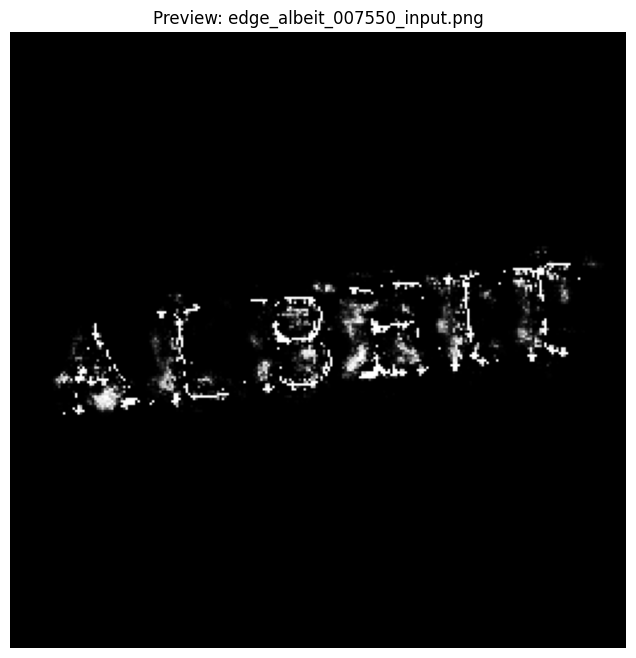

In [6]:
processed_files = list(OUTPUT_DIR.iterdir())

if processed_files:
    # Pak het eerste bestand ter illustratie
    preview_path = processed_files[0]
    preview_img = cv2.imread(str(preview_path), cv2.IMREAD_GRAYSCALE)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(preview_img, cmap='gray')
    plt.title(f"Preview: {preview_path.name}")
    plt.axis('off')
    plt.show()
else:
    print("Geen verwerkte bestanden om te tonen. Staan er beelden in de input map?")